In [12]:
#Aim: to keep the notebook as clean as possible. 

In [2]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr # to read .rds files
import matplotlib.cm as cm

%matplotlib inline

In [3]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
path_rds = "/Users/ud4/Documents/FACEMDS/Models/obs_data"
path_obs_data = "/Users/ud4/Documents/FACEMDS/L2FR_Calc"
path_save_results = "/Users/ud4/Documents/FACEMDS/Figures_Paper"
#path_save_results = "/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/Evaluation_Paper_Dir/Results"

In [4]:
# Load the RDS file
# read mean annual
result = pyreadr.read_r(f'{path_rds}/OBS_ax.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data = result[None]  # None is the key for the single R object in the file

# SE
result = pyreadr.read_r(f'{path_rds}/OBS_ase.rds')
my_data_se = result[None]  # None is the key for the single R object in the file

In [5]:

fnames={}



case_abr = { # case abbreviations
    #"SC" : "FACE_1PFT_r250210_Best_Cal",
    #"SCnew" : "FACE_1PFT_r250421_reCal",
    #"SCnV" : "FACE_1PFT_r250425_MCMCV",
    "EN" :  "FACE_r250424_end2bl",
#    "SD" : "FACE_1PFT_r2503121_SD_b4OLMTparms", 
#    "EC" : "FACE_1PFT_r250314_NoLog_CalParams",
#    "ED" : "FACE_1PFT_r2503121_ED_b4OLMTparms",
#SD: FACE_1PFT_r2503121_SD_b4OLMTparms | it will replace the above

}


site_abr = { # case abbreviations
    "ORNL" : "US-ORN",
    "DUKE" : "US-DUK",
}



sites= ("US-ORN", "US-DUK")
run_cases = ["aCO2", "eCO2"]
sim_cases = [
            "COnly",
            "RD",
            "ECA",
            ]

for c_abr in case_abr:
    case_id = case_abr[c_abr]
    for s_abr in site_abr:
        site = site_abr[s_abr]
        for run_case in run_cases:
            try:
                for i in range(1,22):
                    # COnly
                    fnames[f"{c_abr}_{s_abr}_COnly_{run_case}_g{i:05d}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}_g{i:05d}.nc"
                    # RD
                    #fn = ['RD','ECA']
                    for fn in ['RD','ECA']:
                        fnames[f"{c_abr}_{s_abr}_{fn}_{run_case}_g{i:05d}"] = f"{path_in}{case_id}_{fn}_processed/{case_id}_{fn}_{site}_{run_case}_g{i:05d}.nc"
            except:
                pass

In [6]:
params = {}
params["ORNL"] = {}
params["DUKE"] = {}
params["ORNL"] ["d2bl1"] = np.array([
    0.2, 0.22, 0.24, 0.26, 0.28, 
    0.3, 0.32, 0.34, 0.36, 0.38, 
    0.4, 0.42, 0.44, 0.46, 0.48, 
    0.5, 0.52, 0.54, 0.56, 0.58, 
    0.6
])
params["DUKE"] ["d2bl1"] = np.array([
    0.05, 0.055, 0.06, 0.065, 0.07, 
    0.075, 0.08, 0.085, 0.09, 0.095, 
    0.1, 0.105, 0.11, 0.115, 0.12, 
    0.125, 0.13, 0.135, 0.14, 0.145, 
    0.15
])


In [7]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    try:
        #print (key, ":" , fnames[key])
        ds[key] = xr.open_mfdataset(fnames[key])
        
    except:
        print ("FAIL", key, ":" , fnames[key])
    

FAIL EN_ORNL_RD_aCO2_g00020 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r250424_end2bl_RD_processed/FACE_r250424_end2bl_RD_US-ORN_aCO2_g00020.nc
FAIL EN_ORNL_RD_aCO2_g00021 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r250424_end2bl_RD_processed/FACE_r250424_end2bl_RD_US-ORN_aCO2_g00021.nc
FAIL EN_ORNL_RD_eCO2_g00020 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r250424_end2bl_RD_processed/FACE_r250424_end2bl_RD_US-ORN_eCO2_g00020.nc
FAIL EN_ORNL_RD_eCO2_g00021 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r250424_end2bl_RD_processed/FACE_r250424_end2bl_RD_US-ORN_eCO2_g00021.nc


In [8]:

markers_list = [".", "<", "o","^",".", "<", "o","^"]
colors_list = ["red", "green", "blue", "yellow","red", "green", "blue", "yellow"] 

#def tmp_legend_name (key):
#    return key.replace("FACE_1PFT_r250210_Best_Cal_", "")
    
# How long do you want the simulation plots?
max_r_years = 150
if run_case == "spins":
    output_freq = "yearly" # spins
    multiply_factor = 1 # 365 for daily output; else 1 for yearly
else:
    output_freq = "daily" # spins
    multiply_factor = 365
    if "CO2" in run_case:
        max_r_years = 12+5

In [9]:
# dataframe of selected colms 
# relevant columns
rel_cols = ["YEAR", "co2", "site", "NPP", "NUP"]
# if you want to save the filtered dataframe to CSV
#my_data[rel_cols].to_csv("tmp/obs_a.csv")
df_obs_ax = my_data[rel_cols]
df_obs_ase = my_data_se[rel_cols]

NPP_units = "gC m-2 y-1"
NUP_units = "gN m-2 y-1"

# Filter the dataset to keep only rows where site is 'ORNL' or 'DUKE'
df_obs_ax_site = df_obs_ax[df_obs_ax['site'].isin(['ORNL', 'DUKE'])]
df_obs_ase_site = df_obs_ase[df_obs_ase['site'].isin(['ORNL', 'DUKE'])]

filter_co2 = df_obs_ase_site["co2"] == "AMB"
filter_site = df_obs_ase_site["site"] == "ORNL"
df_obs_ase_site[filter_co2][filter_site]

# arrange data into dict!
dict_obs_ax = {}
sites_o= ("ORNL", "DUKE" )
#sites_o= ( "ORNL", )

CO2_cases  = ("AMB", "ELE" )
dict_obs_ax = {}
dict_obs_ase = {} # standard error
dict_obs_aserel = {} #rel standard error = Val SE/Var
for site in sites_o:
    dict_obs_ax    [site] = {}
    dict_obs_ase   [site] = {}
    dict_obs_aserel [site] = {}
    for co2_case in CO2_cases:
        # selected values from mean
        filter_co2 = df_obs_ax_site["co2"] == co2_case
        filter_site = df_obs_ax_site["site"] == site
        dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
        # selected values from standard error
        filter_co2 = df_obs_ase_site["co2"] == co2_case
        filter_site = df_obs_ase_site["site"] == site
        dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
        dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
        dict_obs_aserel[site][co2_case][["NPP", "NUP"]] = df_obs_ase_site[filter_co2][filter_site][["NPP", "NUP"]]/df_obs_ax_site[filter_co2][filter_site][["NPP", "NUP"]]

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_43630/2440484563.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_43630/2440484563.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_43630/2440484563.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_43630/2440484563.py:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_43630/2440484563.py:43: UserWarn

In [33]:
dict_obs_ax["ORNL"][co2_case].mean()

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_43630/2629438095.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  dict_obs_ax["ORNL"][co2_case].mean()


YEAR    2003.000000
NPP      973.000000
NUP        7.602727
dtype: float64

In [10]:
case_abr

{'EN': 'FACE_r250424_end2bl'}

In [11]:
# make dictionary of plots
# ------------------------
data_plots = {}
data_plots_obs = {}

## Inputs

In [12]:
case_abr

{'EN': 'FACE_r250424_end2bl'}

In [13]:
# Inputs
# ======

case_plot = "EN" # 'SC', 'SD','EC', 'ED','SC_New'
var_obs= "NPP"
data_plots[case_plot] = {}

var_names = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )

# plot obs? 
obs_plot = 1 # 0,1

fig start COnly
Iteration for d2bl1 EN_ORNL_COnly_aCO2_g00001
index, key for var:NPP_alloc, AnnualMean model, AnnualMean obs, d2bl1 value
0,aCO2 g00001:  806.73 vs 819.85 , 0.2
1,aCO2 g00002:  841.25 vs 819.85 , 0.22
2,aCO2 g00003:  869.29 vs 819.85 , 0.24
3,aCO2 g00004:  869.42 vs 819.85 , 0.26
4,aCO2 g00005:  916.39 vs 819.85 , 0.28
5,aCO2 g00006:  940.27 vs 819.85 , 0.3
6,aCO2 g00007:  949.84 vs 819.85 , 0.32
7,aCO2 g00008:  978.83 vs 819.85 , 0.34
8,aCO2 g00009:  992.6 vs 819.85 , 0.36
9,aCO2 g00010:  1004.15 vs 819.85 , 0.38
10,aCO2 g00011:  1021.38 vs 819.85 , 0.4
11,aCO2 g00012:  1033.06 vs 819.85 , 0.42
12,aCO2 g00013:  1047.66 vs 819.85 , 0.44
13,aCO2 g00014:  1062.05 vs 819.85 , 0.46
14,aCO2 g00015:  1069.35 vs 819.85 , 0.48
15,aCO2 g00016:  1078.25 vs 819.85 , 0.5
16,aCO2 g00017:  515.94 vs 819.85 , 0.52
17,aCO2 g00018:  527.09 vs 819.85 , 0.54
18,aCO2 g00019:  534.81 vs 819.85 , 0.56
19,aCO2 g00020:  546.89 vs 819.85 , 0.58
20,aCO2 g00021:  560.41 vs 819.85 , 0.6
Iteration 

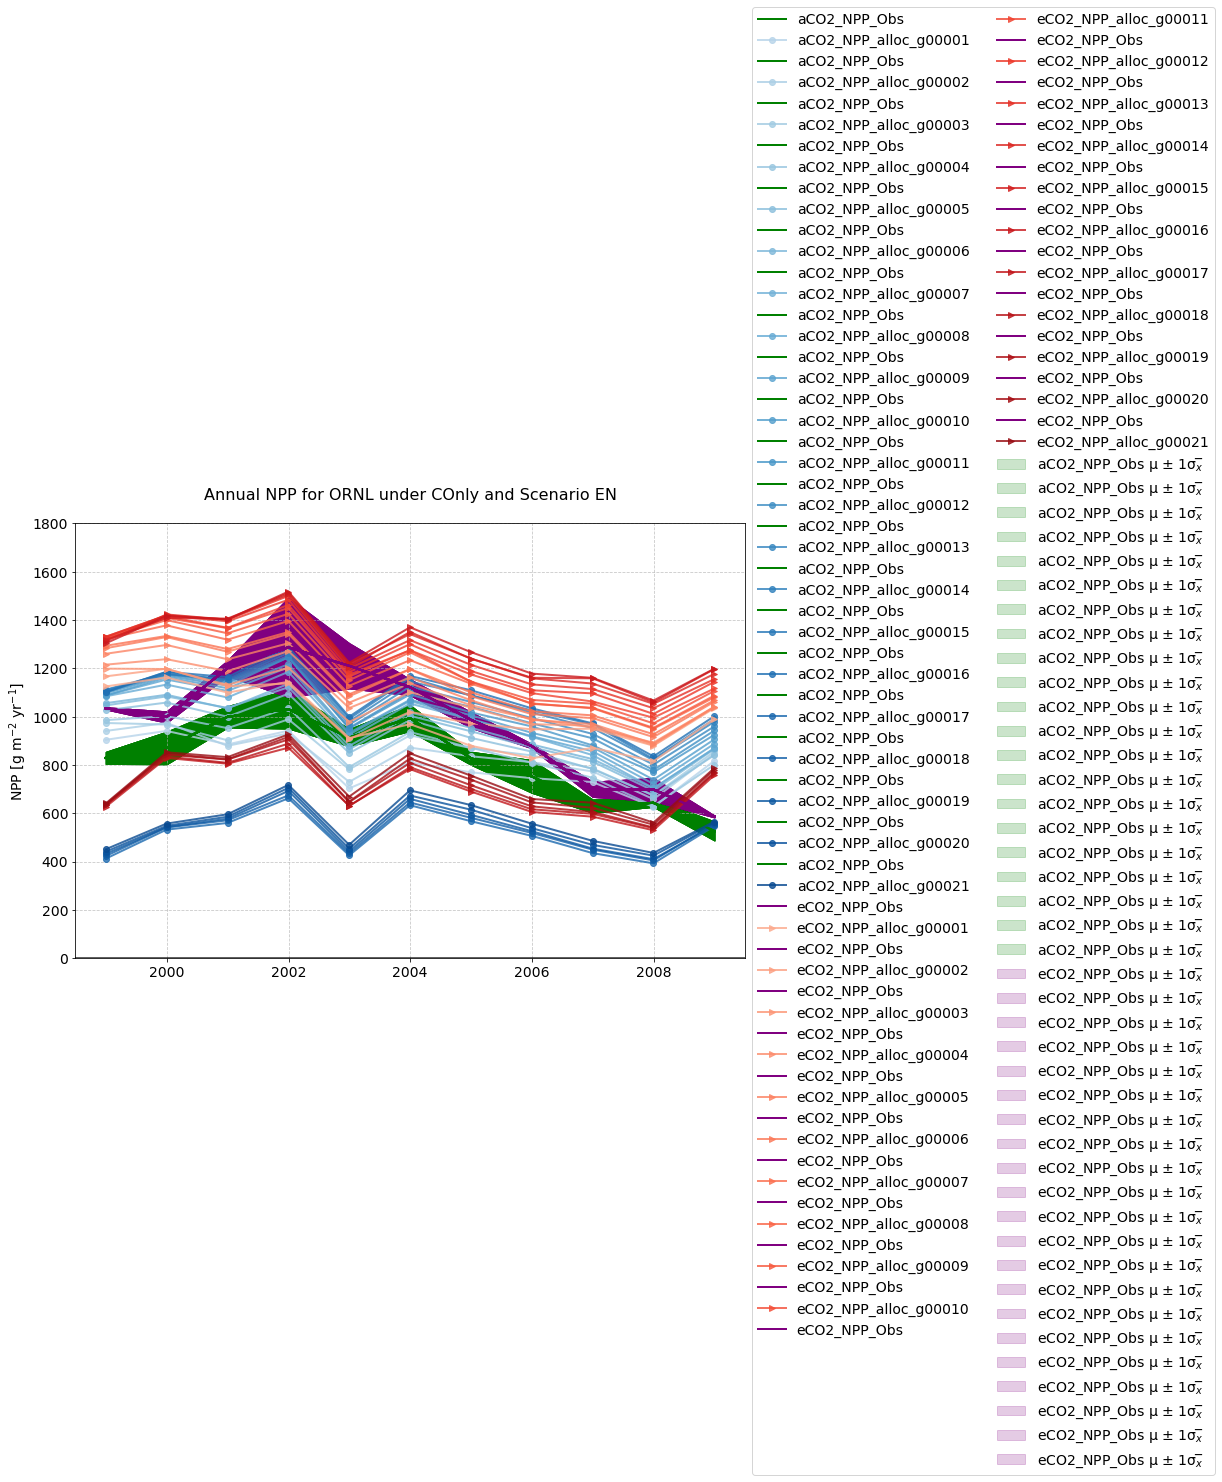

fig start RD
Iteration for d2bl1 EN_ORNL_RD_aCO2_g00001
index, key for var:NPP_alloc, AnnualMean model, AnnualMean obs, d2bl1 value
0,aCO2 g00001:  798.42 vs 819.85 , 0.2
1,aCO2 g00002:  830.52 vs 819.85 , 0.22
2,aCO2 g00003:  849.39 vs 819.85 , 0.24
3,aCO2 g00004:  880.96 vs 819.85 , 0.26
4,aCO2 g00005:  888.5 vs 819.85 , 0.28
5,aCO2 g00006:  785.56 vs 819.85 , 0.3
6,aCO2 g00007:  760.13 vs 819.85 , 0.32
7,aCO2 g00008:  777.34 vs 819.85 , 0.34
8,aCO2 g00009:  763.86 vs 819.85 , 0.36
9,aCO2 g00010:  611.7 vs 819.85 , 0.38
10,aCO2 g00011:  763.39 vs 819.85 , 0.4
11,aCO2 g00012:  750.39 vs 819.85 , 0.42
12,aCO2 g00013:  739.06 vs 819.85 , 0.44
13,aCO2 g00014:  742.44 vs 819.85 , 0.46
14,aCO2 g00015:  692.35 vs 819.85 , 0.48
15,aCO2 g00016:  702.16 vs 819.85 , 0.5
16,aCO2 g00017:  711.53 vs 819.85 , 0.52
17,aCO2 g00018:  708.8 vs 819.85 , 0.54
18,aCO2 g00019:  708.5 vs 819.85 , 0.56
Iteration for d2bl1 EN_ORNL_RD_eCO2_g00001
index, key for var:NPP_alloc, AnnualMean model, AnnualMean obs, 

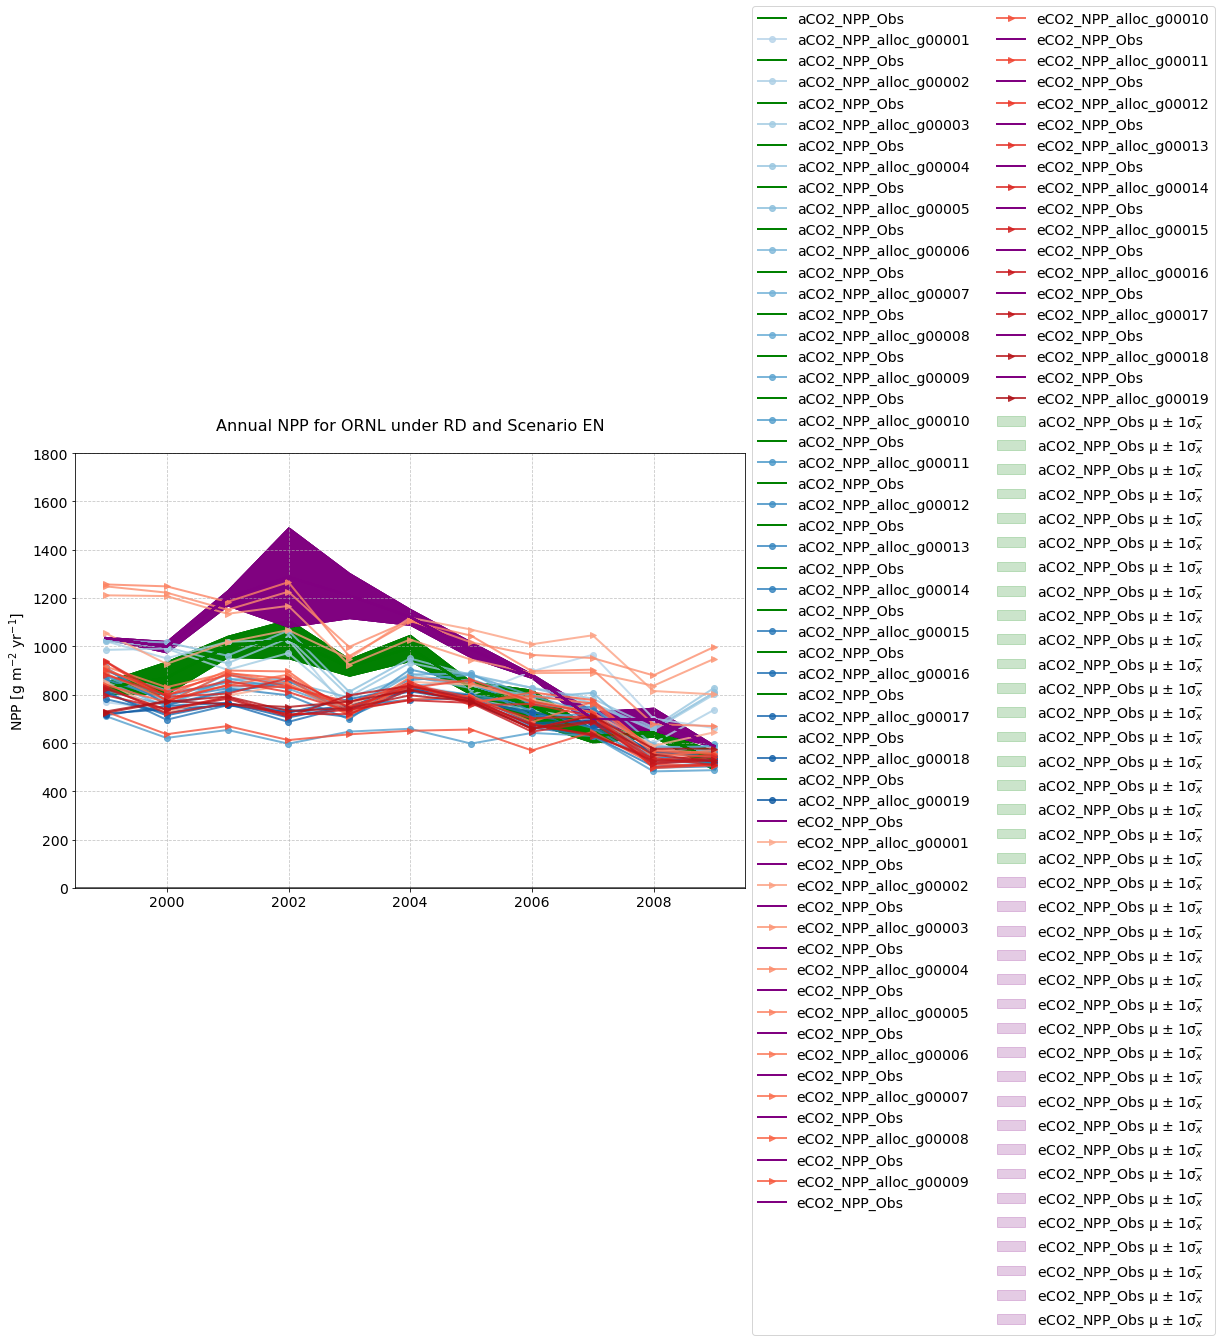

fig start ECA
Iteration for d2bl1 EN_ORNL_ECA_aCO2_g00001
index, key for var:NPP_alloc, AnnualMean model, AnnualMean obs, d2bl1 value
0,aCO2 g00001:  724.64 vs 819.85 , 0.2
1,aCO2 g00002:  774.37 vs 819.85 , 0.22
2,aCO2 g00003:  791.73 vs 819.85 , 0.24
3,aCO2 g00004:  818.17 vs 819.85 , 0.26
4,aCO2 g00005:  720.58 vs 819.85 , 0.28
5,aCO2 g00006:  847.3 vs 819.85 , 0.3
6,aCO2 g00007:  646.39 vs 819.85 , 0.32
7,aCO2 g00008:  745.41 vs 819.85 , 0.34
8,aCO2 g00009:  698.27 vs 819.85 , 0.36
9,aCO2 g00010:  685.82 vs 819.85 , 0.38
10,aCO2 g00011:  652.46 vs 819.85 , 0.4
11,aCO2 g00012:  649.77 vs 819.85 , 0.42
12,aCO2 g00013:  641.36 vs 819.85 , 0.44
13,aCO2 g00014:  631.57 vs 819.85 , 0.46
14,aCO2 g00015:  618.08 vs 819.85 , 0.48
15,aCO2 g00016:  621.32 vs 819.85 , 0.5
16,aCO2 g00017:  635.71 vs 819.85 , 0.52
17,aCO2 g00018:  5.82 vs 819.85 , 0.54
18,aCO2 g00019:  5.38 vs 819.85 , 0.56
19,aCO2 g00020:  673.72 vs 819.85 , 0.58
20,aCO2 g00021:  672.68 vs 819.85 , 0.6
Iteration for d2bl1 EN_OR

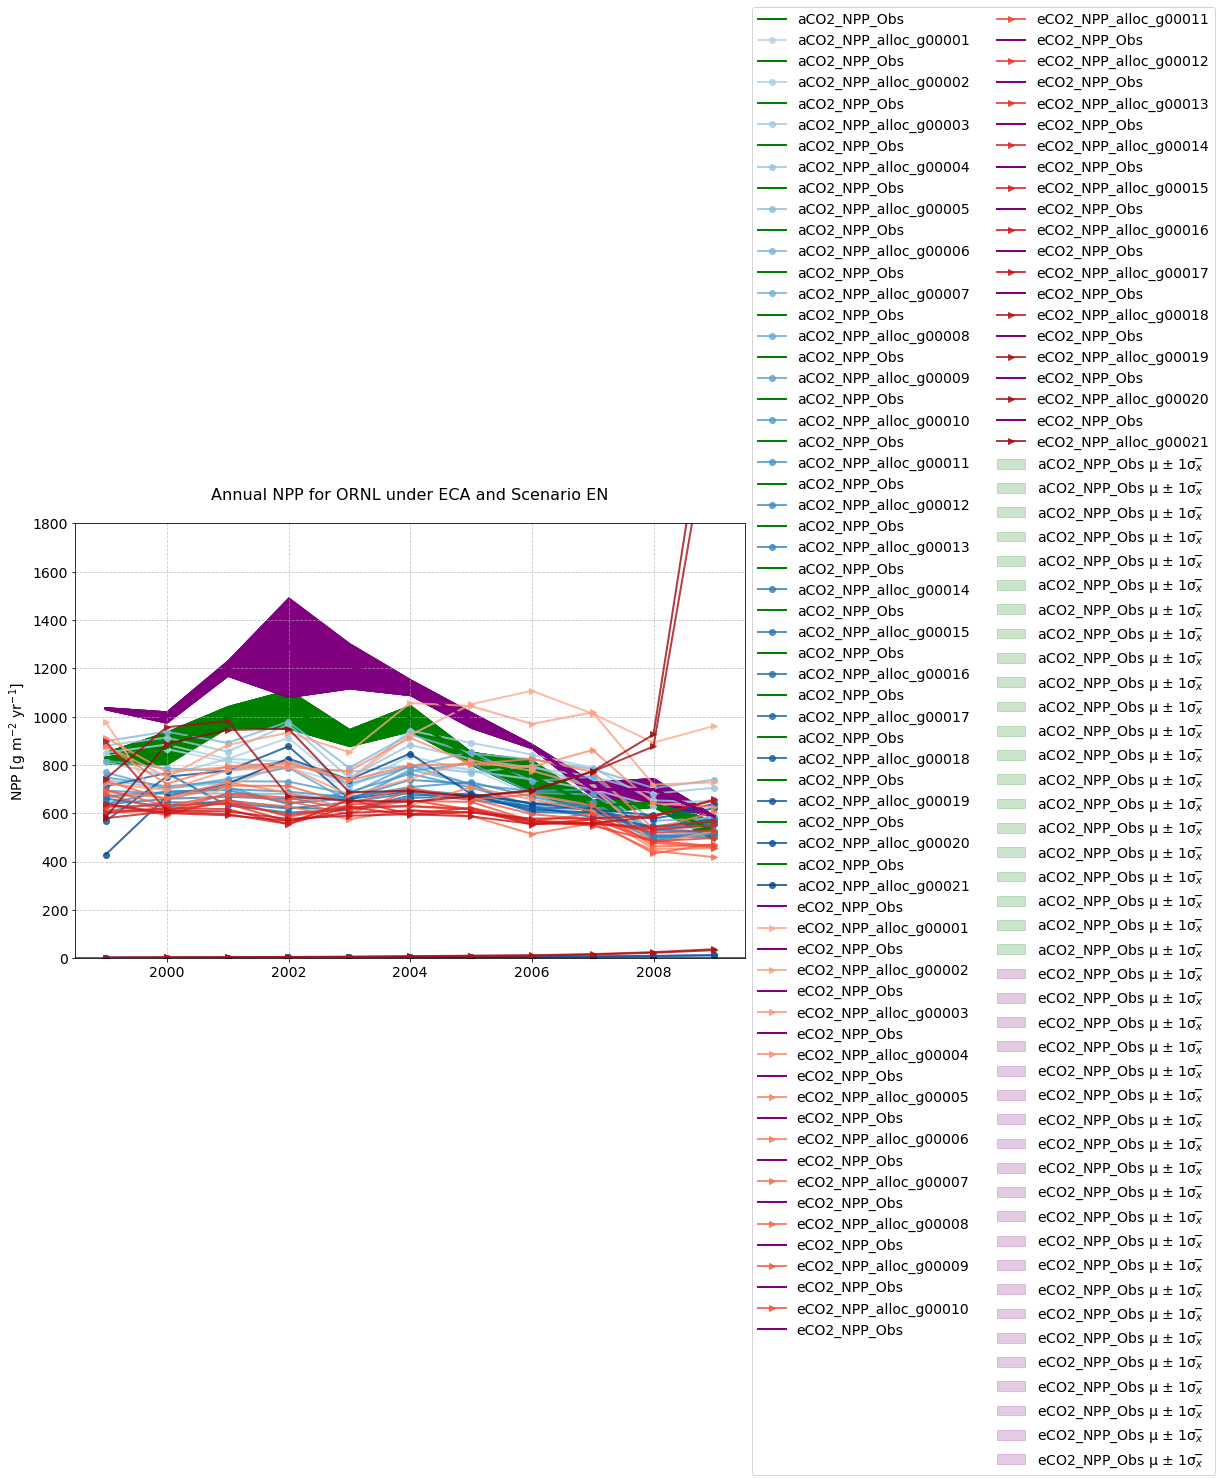

In [44]:

select_site = "US-ORN"
site = "ORNL"

data_plots[case_plot][site] = {}
data_plots_obs[site] = {}
colors_b = cm.Blues(np.linspace(0.3, 0.9, 21))  
colors_r = cm.Reds(np.linspace(0.3, 0.9, 21))  
li = 0 # for legend index
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in var_names:
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
        bi = -1; ri=-1 # color line nde
        try:
            for idx, key in enumerate(ds.keys()):
                if sim_case not in key:
                    continue
                if (f"{site}" in key) and (f"{case_plot}_" in key): 
                    time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                    if "aCO2" in key:
                        bi=bi+1
                        color_line = colors_b[bi]
                        marker_line = "o"
                        co2_case = "AMB"
                        tmp_case = "aCO2"
                        color_obs = "green"
                        data_plots_obs[site][var_obs][tmp_case] = {}
                    if "eCO2" in key:
                        ri=ri+1
                        color_line = colors_r[ri]
                        marker_line = ">"
                        co2_case = "ELE"
                        tmp_case = "eCO2"
                        color_obs = "purple"
                        data_plots_obs[site][var_obs][tmp_case] = {}
                    if (obs_plot ==1):# and (ran_twice<7):
                        Mean_DF = dict_obs_ax[site][co2_case]
                        Standard_error_DF = dict_obs_ase[site][co2_case]
                        # Extracting the relevant columns
                        years = Mean_DF['YEAR']
                        mean_npp = Mean_DF[f'{var_obs}']
                        se_npp = Standard_error_DF[f'{var_obs}']
                        # Plot NPP with shaded error bars
                        plt.plot(time, mean_npp, label=f'{tmp_case}_{var_obs}_Obs', color=color_obs, lw=2)
                        plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'{tmp_case}_{var_obs}_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                        #plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                        data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                        data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                        data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                        data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                        ran_twice +=1

                    if var =="FATES_NPP-FATES_EXCESS_RESP":
                        tmp_var = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000   
                        plt.plot(time, tmp_var.groupby("time.year").mean(), 
                                 #label = tmp_legend_name(key).split('_')[-1]+'_'+ "NPP-ExResp", 
                                 label = tmp_case + '_'+ "NPP-ExResp", 
                                 color = color_line,
                                 marker = marker_line,
                                 linestyle = "--",
                                 alpha=.8, linewidth=2) 
                        data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                        #plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                    if var == "NPP_alloc":
                        tmp_var = ( 
                            ds[key]['FATES_CROOT_ALLOC'] +
                            ds[key]['FATES_FROOT_ALLOC'] +
                            ds[key]['FATES_LEAF_ALLOC'] +
                            ds[key]['FATES_SEED_ALLOC'] +
                            ds[key]['FATES_STEM_ALLOC'] 
                        )*24*3600*365*1000   
                        plt.plot(time, tmp_var.groupby("time.year").mean(), 
                                 #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                                 label = tmp_case + '_'+ "NPP_alloc_"+key.split('_')[-1], 
                                 color = color_line,
                                 marker = marker_line,
                                 alpha=.8, linewidth=2)
                        data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                        #plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)
                        #print (f"{tmp_case} {key.split('_')[-1]}:  {round(float(tmp_var.groupby('time.year').mean().mean().values),2)} vs {round(mean_npp.mean(),2)}" )
                        try:
                            
                            if int(key.split('_')[-1][-2:])-1 == 0:
                                print ("Iteration for d2bl1",key)
                                print ("index,",f"key for var:{var},", "AnnualMean model,", "AnnualMean obs,", "d2bl1 value")
                            print (f"{int(key.split('_')[-1][-2:])-1},{tmp_case} {key.split('_')[-1]}:  {round(float(tmp_var.groupby('time.year').mean().mean().values),2)} vs {round(mean_npp.mean(),2)}", 
                                   ",", params[f"{site}"] ["d2bl1"][int(key.split('_')[-1][-2:])-1] )
                        except:
                            pass

                    if False:
                        print (ds[key][var].long_name )
                    plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                    plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                    plt.legend(fontsize=14, ncol=2, loc='center left', bbox_to_anchor=(1, 0.5))
                    plt.ylabel(r"NPP [g m$^{-2}$ yr$^{-1}$]", fontsize=14)
                    plt.xticks(fontsize=14)  # Increase x-axis tick font size
                    plt.yticks(fontsize=14)  # Increase y-axis tick font size
                    plt.ylim(0,1800)
                    plt.title(f"Annual NPP for {site} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                    #li+=1 # for legend index updating for a site
        except:
            pass
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf")
    #plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    #plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
    plt.show()
    plt.close()

In [15]:
print (f"{tmp_case} {key.split('_')[-1]}:  {round(float(tmp_var.groupby('time.year').mean().mean().values),2)} vs {round(mean_npp.mean(),2)}" )

eCO2 g00021:  941.09 vs 819.85


fig start COnly
Iteration for d2bl1
index, key for var:NPP_alloc, AnnualMean model, AnnualMean obs, d2bl1 value
0,aCO2 g00001:  453.57 vs 997.92 , 0.05
1,aCO2 g00002:  454.86 vs 997.92 , 0.055
2,aCO2 g00003:  695.26 vs 997.92 , 0.06
3,aCO2 g00004:  683.92 vs 997.92 , 0.065
4,aCO2 g00005:  672.58 vs 997.92 , 0.07
5,aCO2 g00006:  675.75 vs 997.92 , 0.075
6,aCO2 g00007:  666.69 vs 997.92 , 0.08
7,aCO2 g00008:  654.99 vs 997.92 , 0.085
8,aCO2 g00009:  646.34 vs 997.92 , 0.09
9,aCO2 g00010:  636.43 vs 997.92 , 0.095
10,aCO2 g00011:  621.45 vs 997.92 , 0.1
11,aCO2 g00012:  601.01 vs 997.92 , 0.105
12,aCO2 g00013:  591.04 vs 997.92 , 0.11
13,aCO2 g00014:  572.67 vs 997.92 , 0.115
14,aCO2 g00015:  551.55 vs 997.92 , 0.12
15,aCO2 g00016:  517.28 vs 997.92 , 0.125
16,aCO2 g00017:  505.51 vs 997.92 , 0.13
17,aCO2 g00018:  492.89 vs 997.92 , 0.135
18,aCO2 g00019:  481.19 vs 997.92 , 0.14
19,aCO2 g00020:  466.53 vs 997.92 , 0.145
20,aCO2 g00021:  452.53 vs 997.92 , 0.15
Iteration for d2bl1
index, k

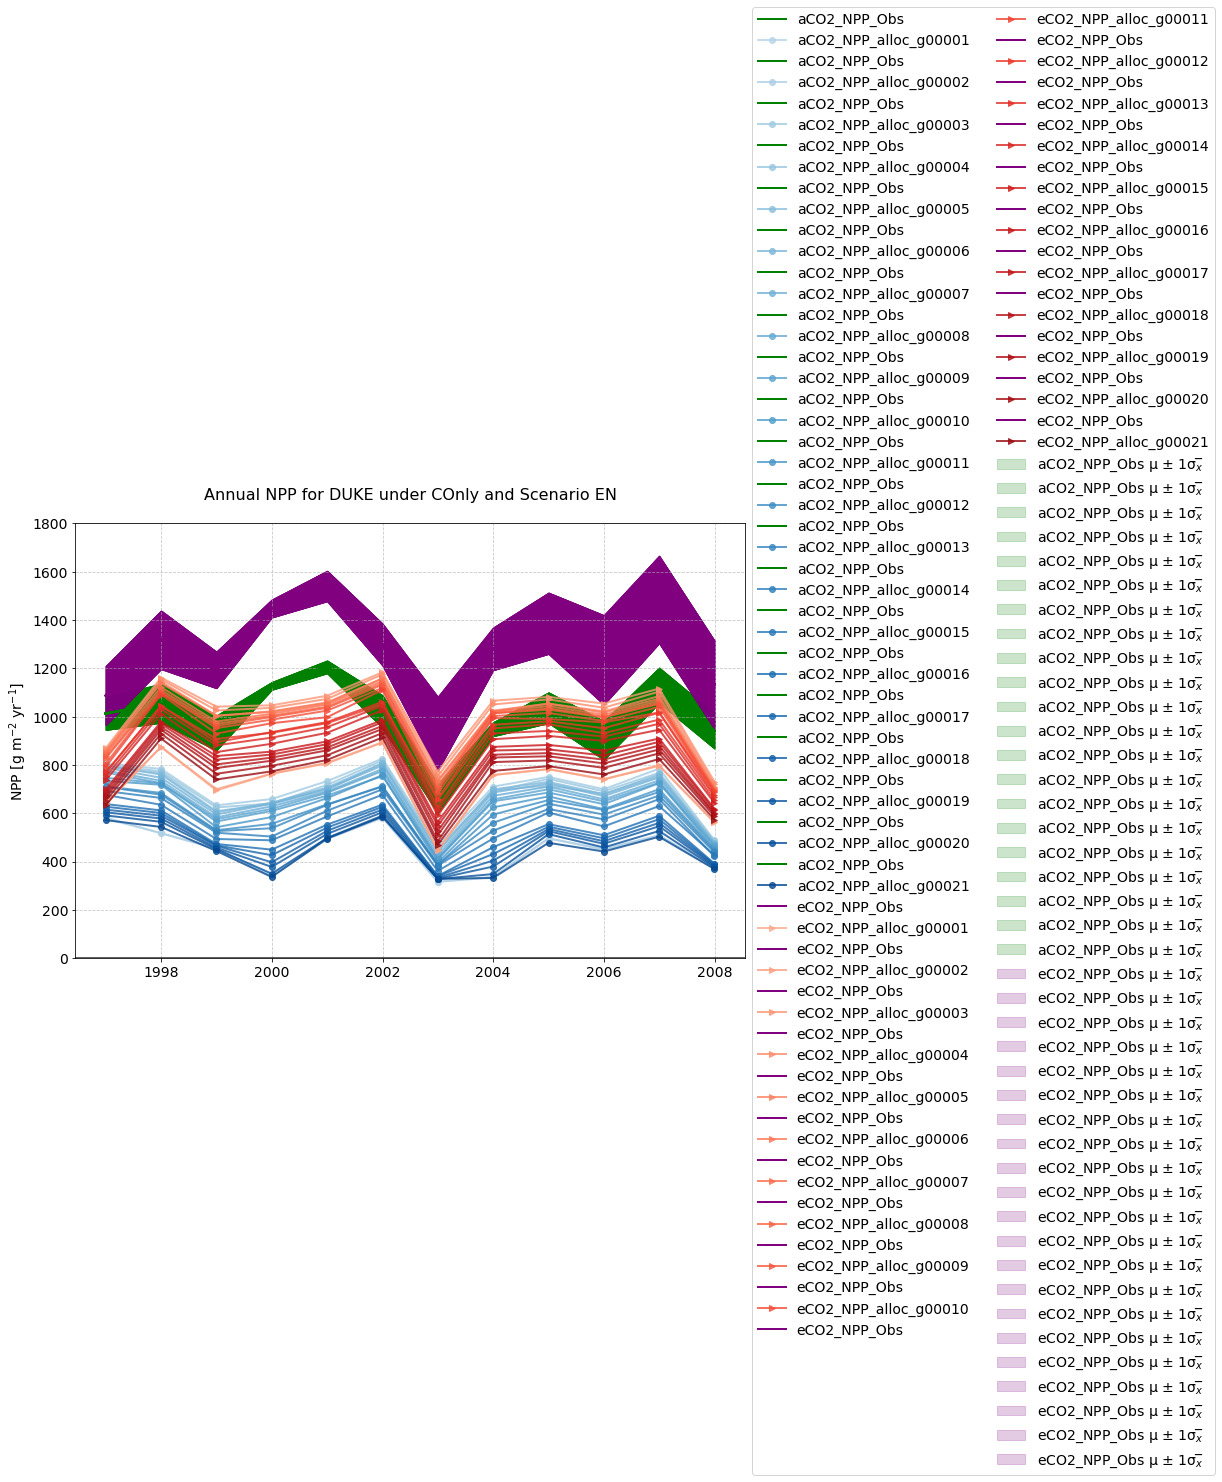

fig start RD
Iteration for d2bl1
index, key for var:NPP_alloc, AnnualMean model, AnnualMean obs, d2bl1 value
0,aCO2 g00001:  995.06 vs 997.92 , 0.05
1,aCO2 g00002:  994.87 vs 997.92 , 0.055
2,aCO2 g00003:  987.87 vs 997.92 , 0.06
3,aCO2 g00004:  1002.23 vs 997.92 , 0.065
4,aCO2 g00005:  1013.56 vs 997.92 , 0.07
5,aCO2 g00006:  485.11 vs 997.92 , 0.075
6,aCO2 g00007:  426.58 vs 997.92 , 0.08
7,aCO2 g00008:  567.4 vs 997.92 , 0.085
8,aCO2 g00009:  578.78 vs 997.92 , 0.09
9,aCO2 g00010:  577.29 vs 997.92 , 0.095
10,aCO2 g00011:  484.99 vs 997.92 , 0.1
11,aCO2 g00012:  540.67 vs 997.92 , 0.105
12,aCO2 g00013:  420.97 vs 997.92 , 0.11
13,aCO2 g00014:  397.91 vs 997.92 , 0.115
14,aCO2 g00015:  510.5 vs 997.92 , 0.12
15,aCO2 g00016:  358.44 vs 997.92 , 0.125
16,aCO2 g00017:  339.37 vs 997.92 , 0.13
17,aCO2 g00018:  355.47 vs 997.92 , 0.135
18,aCO2 g00019:  331.98 vs 997.92 , 0.14
19,aCO2 g00020:  374.77 vs 997.92 , 0.145
20,aCO2 g00021:  376.74 vs 997.92 , 0.15
Iteration for d2bl1
index, key 

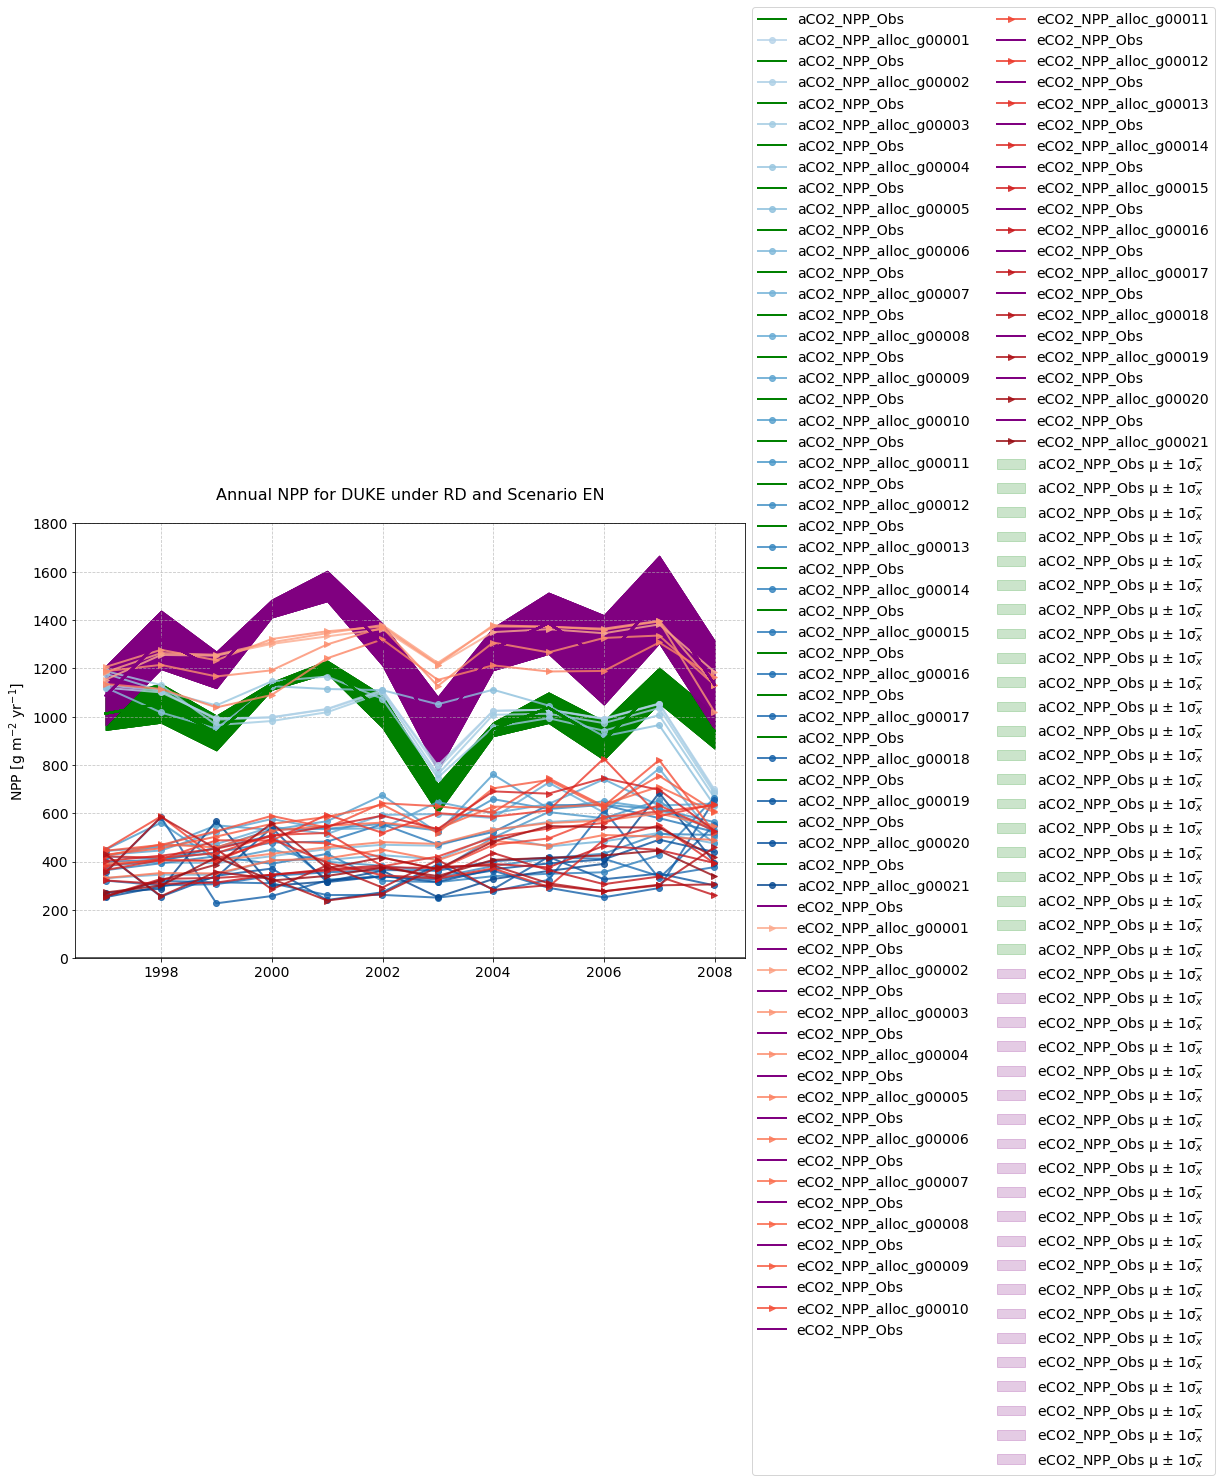

fig start ECA
Iteration for d2bl1
index, key for var:NPP_alloc, AnnualMean model, AnnualMean obs, d2bl1 value
0,aCO2 g00001:  1062.33 vs 997.92 , 0.05
1,aCO2 g00002:  1060.18 vs 997.92 , 0.055
2,aCO2 g00003:  1045.16 vs 997.92 , 0.06
3,aCO2 g00004:  1024.53 vs 997.92 , 0.065
4,aCO2 g00005:  1001.62 vs 997.92 , 0.07
5,aCO2 g00006:  1036.69 vs 997.92 , 0.075
6,aCO2 g00007:  975.28 vs 997.92 , 0.08
7,aCO2 g00008:  980.97 vs 997.92 , 0.085
8,aCO2 g00009:  1000.52 vs 997.92 , 0.09
9,aCO2 g00010:  1015.64 vs 997.92 , 0.095
10,aCO2 g00011:  999.21 vs 997.92 , 0.1
11,aCO2 g00012:  973.91 vs 997.92 , 0.105
12,aCO2 g00013:  929.36 vs 997.92 , 0.11
13,aCO2 g00014:  821.45 vs 997.92 , 0.115
14,aCO2 g00015:  913.45 vs 997.92 , 0.12
15,aCO2 g00016:  749.62 vs 997.92 , 0.125
16,aCO2 g00017:  727.36 vs 997.92 , 0.13
17,aCO2 g00018:  793.33 vs 997.92 , 0.135
18,aCO2 g00019:  611.5 vs 997.92 , 0.14
19,aCO2 g00020:  663.19 vs 997.92 , 0.145
20,aCO2 g00021:  536.9 vs 997.92 , 0.15
Iteration for d2bl1
inde

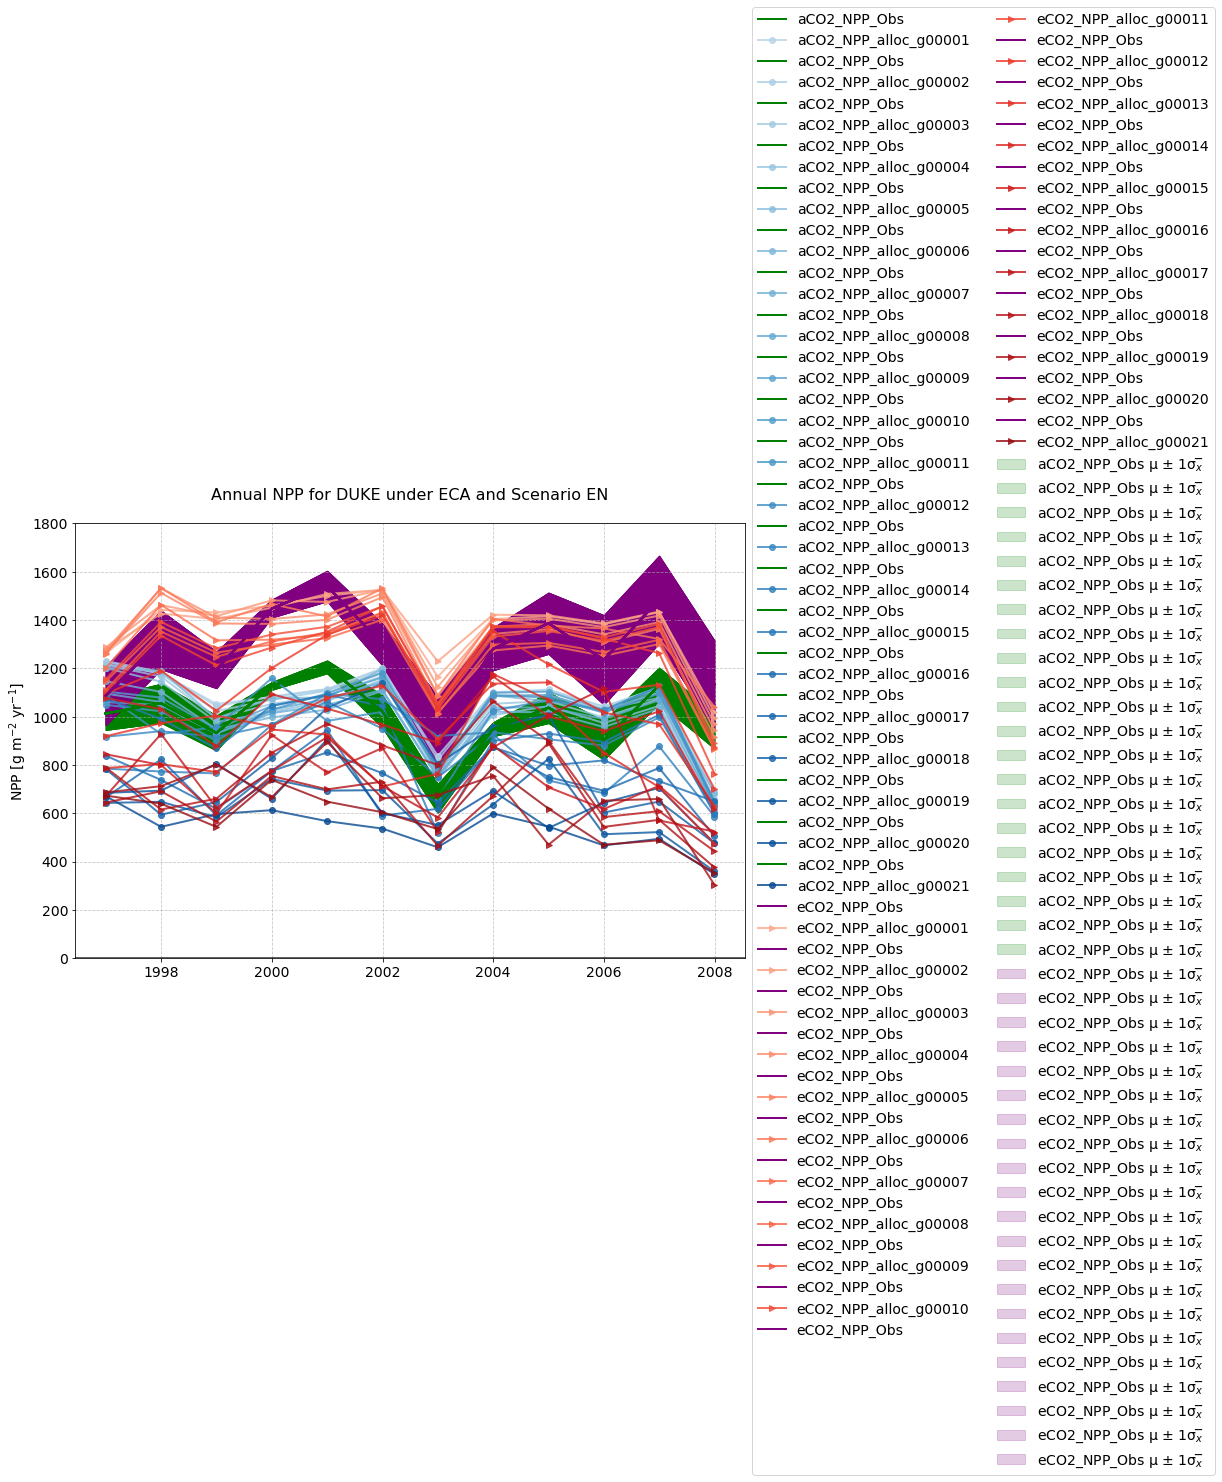

In [66]:
select_site = "US-DUK"
site = "DUKE"

data_plots[case_plot][site] = {}
data_plots_obs[site] = {}
colors_b = cm.Blues(np.linspace(0.3, 0.9, 21))  
colors_r = cm.Reds(np.linspace(0.3, 0.9, 21))  
li = 0 # for legend index
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in var_names:
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
        bi = -1; ri=-1 # color line nde
        try:
            for idx, key in enumerate(ds.keys()):
                if sim_case not in key:
                    continue
                if (f"{site}" in key) and (f"{case_plot}_" in key): 
                    time = pd.date_range("1996-01-01", "2007-12-31", freq="A")  # Monthly data
                    if "aCO2" in key:
                        bi=bi+1
                        color_line = colors_b[bi]
                        marker_line = "o"
                        co2_case = "AMB"
                        tmp_case = "aCO2"
                        color_obs = "green"
                        data_plots_obs[site][var_obs][tmp_case] = {}
                    if "eCO2" in key:
                        ri=ri+1
                        color_line = colors_r[ri]
                        marker_line = ">"
                        co2_case = "ELE"
                        tmp_case = "eCO2"
                        color_obs = "purple"
                        data_plots_obs[site][var_obs][tmp_case] = {}
                    if (obs_plot ==1):# and (ran_twice<2):
                        Mean_DF = dict_obs_ax[site][co2_case]
                        Standard_error_DF = dict_obs_ase[site][co2_case]
                        # Extracting the relevant columns
                        years = Mean_DF['YEAR']
                        mean_npp = Mean_DF[f'{var_obs}']
                        se_npp = Standard_error_DF[f'{var_obs}']
                        # Plot NPP with shaded error bars
                        plt.plot(time, mean_npp, label=f'{tmp_case}_{var_obs}_Obs', color=color_obs, lw=2)
                        plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'{tmp_case}_{var_obs}_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                        #plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                        data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                        data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                        data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                        data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                        ran_twice +=1

                    if var =="FATES_NPP-FATES_EXCESS_RESP":
                        tmp_var = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000   
                        plt.plot(time, tmp_var.groupby("time.year").mean(), 
                                 #label = tmp_legend_name(key).split('_')[-1]+'_'+ "NPP-ExResp", 
                                 label = tmp_case + '_'+ "NPP-ExResp", 
                                 color = color_line,
                                 marker = marker_line,
                                 linestyle = "--",
                                 alpha=.8, linewidth=2) 
                        data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                        #plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                    if var == "NPP_alloc":
                        tmp_var = ( 
                            ds[key]['FATES_CROOT_ALLOC'] +
                            ds[key]['FATES_FROOT_ALLOC'] +
                            ds[key]['FATES_LEAF_ALLOC'] +
                            ds[key]['FATES_SEED_ALLOC'] +
                            ds[key]['FATES_STEM_ALLOC'] 
                        )*24*3600*365*1000   
                        plt.plot(time, tmp_var.groupby("time.year").mean(), 
                                 #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                                 label = tmp_case + '_'+ "NPP_alloc_"+key.split('_')[-1], 
                                 color = color_line,
                                 marker = marker_line,
                                 alpha=.8, linewidth=2)
                        data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                        #plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)
                        #print (f"{tmp_case} {key.split('_')[-1]}:  {round(float(tmp_var.groupby('time.year').mean().mean().values),2)} vs {round(mean_npp.mean(),2)}" )
                        try:
                            
                            if int(key.split('_')[-1][-2:])-1 == 0:
                                print ("Iteration for d2bl1")
                                print ("index,",f"key for var:{var},", "AnnualMean model,", "AnnualMean obs,", "d2bl1 value")
                            print (f"{int(key.split('_')[-1][-2:])-1},{tmp_case} {key.split('_')[-1]}:  {round(float(tmp_var.groupby('time.year').mean().mean().values),2)} vs {round(mean_npp.mean(),2)}", 
                                   ",", params[f"{site}"] ["d2bl1"][int(key.split('_')[-1][-2:])-1] )
                        except:
                            pass

                    if False:
                        print (ds[key][var].long_name )
                    if False:
                        print (ds[key][var].long_name )
                    plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                    plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                    plt.legend(fontsize=14, ncol=2, loc='center left', bbox_to_anchor=(1, 0.5))
                    plt.ylabel(r"NPP [g m$^{-2}$ yr$^{-1}$]", fontsize=14)
                    plt.xticks(fontsize=14)  # Increase x-axis tick font size
                    plt.yticks(fontsize=14)  # Increase y-axis tick font size
                    plt.ylim(0,1800)
                    plt.title(f"Annual NPP for {site} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                    #li+=1 # for legend index updating for a site
        except:
            pass
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf")
    #plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    #plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
    plt.show()
    plt.close()

In [17]:
ds.keys()

dict_keys(['EN_ORNL_COnly_aCO2_g00001', 'EN_ORNL_RD_aCO2_g00001', 'EN_ORNL_ECA_aCO2_g00001', 'EN_ORNL_COnly_aCO2_g00002', 'EN_ORNL_RD_aCO2_g00002', 'EN_ORNL_ECA_aCO2_g00002', 'EN_ORNL_COnly_aCO2_g00003', 'EN_ORNL_RD_aCO2_g00003', 'EN_ORNL_ECA_aCO2_g00003', 'EN_ORNL_COnly_aCO2_g00004', 'EN_ORNL_RD_aCO2_g00004', 'EN_ORNL_ECA_aCO2_g00004', 'EN_ORNL_COnly_aCO2_g00005', 'EN_ORNL_RD_aCO2_g00005', 'EN_ORNL_ECA_aCO2_g00005', 'EN_ORNL_COnly_aCO2_g00006', 'EN_ORNL_RD_aCO2_g00006', 'EN_ORNL_ECA_aCO2_g00006', 'EN_ORNL_COnly_aCO2_g00007', 'EN_ORNL_RD_aCO2_g00007', 'EN_ORNL_ECA_aCO2_g00007', 'EN_ORNL_COnly_aCO2_g00008', 'EN_ORNL_RD_aCO2_g00008', 'EN_ORNL_ECA_aCO2_g00008', 'EN_ORNL_COnly_aCO2_g00009', 'EN_ORNL_RD_aCO2_g00009', 'EN_ORNL_ECA_aCO2_g00009', 'EN_ORNL_COnly_aCO2_g00010', 'EN_ORNL_RD_aCO2_g00010', 'EN_ORNL_ECA_aCO2_g00010', 'EN_ORNL_COnly_aCO2_g00011', 'EN_ORNL_RD_aCO2_g00011', 'EN_ORNL_ECA_aCO2_g00011', 'EN_ORNL_COnly_aCO2_g00012', 'EN_ORNL_RD_aCO2_g00012', 'EN_ORNL_ECA_aCO2_g00012', 'EN_O

In [18]:
select_keys = ["EN_ORNL_RD_aCO2_g00011", "EN_ORNL_aCO2_g00011","EN_ORNL_ECA_aCO2_g00011"]

/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EN_ORNL_COnly_Response.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EN_ORNL_RD_Response.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EN_ORNL_ECA_Response.pdf


<Figure size 864x432 with 0 Axes>

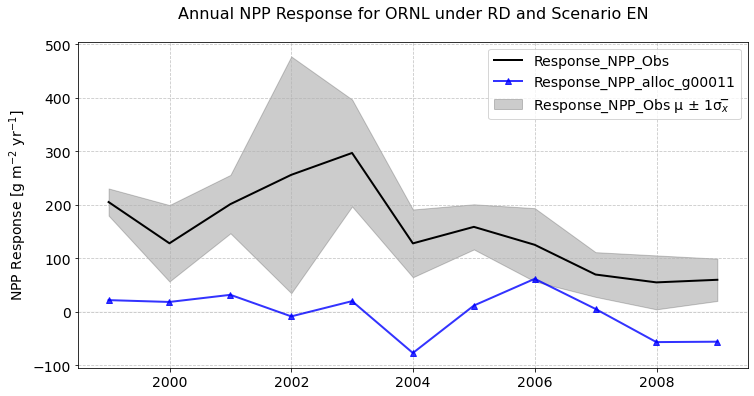

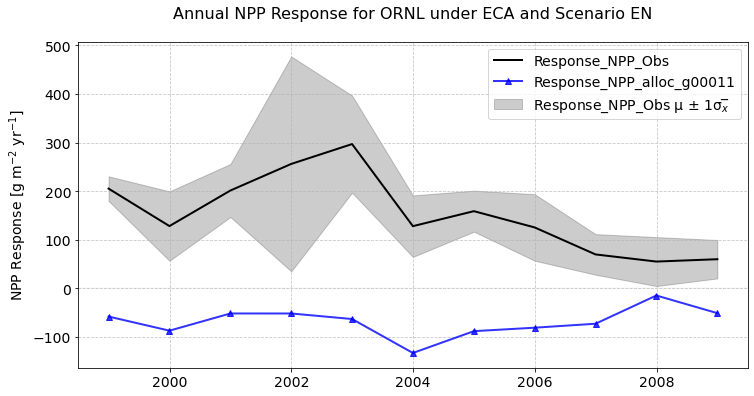

In [19]:
# NPP Response for ORNL
select_site = "US-ORN"
site = "ORNL"
li = 0  # for legend index
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12, 6))
    for var in var_names:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if key not in select_keys:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range(
                    "1998-01-01", "2008-12-31", freq="A"
                )  # Monthly data
                color_obs = "k"

                if (obs_plot == 1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = (
                        Mean_DF1[["YEAR", "NPP", "NUP"]]
                        - Mean_DF0[["YEAR", "NPP", "NUP"]]
                    )
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                        drop=True
                    )
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                        drop=True
                    )

                    Standard_error_DF = (
                        (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                        + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                    ) ** 0.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                    tmp_case = "Response"

                    # Extracting the relevant columns
                    years = Mean_DF["YEAR"]
                    mean_npp = Mean_DF["NPP"]
                    se_npp = Standard_error_DF["NPP"]
                    # Plot NPP with shaded error bars
                    plt.plot(
                        time,
                        mean_npp,
                        label=f"Response_NPP_Obs",
                        color=color_obs,
                        lw=2,
                    )
                    plt.fill_between(
                        time,
                        mean_npp - se_npp,
                        mean_npp + se_npp,
                        label=f"Response_NPP_Obs μ ± 1σ$_x̅$",
                        color=color_obs,
                        alpha=0.2,
                    )
                    data_plots_obs[site][var_obs][tmp_case] = {}
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                    #plt.fill_between(
                    #    time,
                    #    mean_npp - se_npp * 1.96,
                    #    mean_npp + se_npp * 1.96,
                    #    color=color_obs,
                    #    alpha=0.15,
                    #)

                    ran_once = True

                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var == "FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (
                        (ds[key][var.split("-")[0]] - ds[key][var.split("-")[1]])
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2][var.split("-")[0]]
                            - ds[key_eCO2][var.split("-")[1]]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )

                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + "NPP-ExResp",
                        color=color_line,
                        marker=marker_line,
                        linestyle="--",
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = (
                        (
                            ds[key]["FATES_CROOT_ALLOC"]
                            + ds[key]["FATES_FROOT_ALLOC"]
                            + ds[key]["FATES_LEAF_ALLOC"]
                            + ds[key]["FATES_SEED_ALLOC"]
                            + ds[key]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2]["FATES_CROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                            + ds[key_eCO2]["FATES_SEED_ALLOC"]
                            + ds[key_eCO2]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + var
                        + "_"+ key.split('_')[-1], 
                        color=color_line,
                        marker=marker_line,
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)
                if False:
                    print(ds[key][var].long_name)
                plt.axhline(y=0, color="k", lw=2, alpha=0.02)
                plt.grid(
                    True, linestyle="--", alpha=0.7
                )  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"NPP Response [g m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                #plt.ylim(0, 500)
                plt.title(
                    f"Annual NPP Response for {site} under {sim_case} and Scenario {case_plot}\n",
                    fontsize=16,
                )
                # li+=1 # for legend index updating for a sit

    print(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf"
    )
    '''
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )
    '''
    

In [20]:
select_keys = ["EN_DUKE_RD_aCO2_g00004", "EN_DUKE_aCO2_g00004","EN_DUKE_ECA_aCO2_g00004"]

In [21]:
# NPP Response for ORNL
select_site = "US-ORN"
site = "ORNL"
li = 0  # for legend index
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12, 6))
    for var in var_names:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if key not in select_keys:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range(
                    "1998-01-01", "2008-12-31", freq="A"
                )  # Monthly data
                color_obs = "k"

                if (obs_plot == 1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = (
                        Mean_DF1[["YEAR", "NPP", "NUP"]]
                        - Mean_DF0[["YEAR", "NPP", "NUP"]]
                    )
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                        drop=True
                    )
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                        drop=True
                    )

                    Standard_error_DF = (
                        (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                        + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                    ) ** 0.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                    tmp_case = "Response"

                    # Extracting the relevant columns
                    years = Mean_DF["YEAR"]
                    mean_npp = Mean_DF["NPP"]
                    se_npp = Standard_error_DF["NPP"]
                    # Plot NPP with shaded error bars
                    plt.plot(
                        time,
                        mean_npp,
                        label=f"Response_NPP_Obs",
                        color=color_obs,
                        lw=2,
                    )
                    plt.fill_between(
                        time,
                        mean_npp - se_npp,
                        mean_npp + se_npp,
                        label=f"Response_NPP_Obs μ ± 1σ$_x̅$",
                        color=color_obs,
                        alpha=0.2,
                    )
                    data_plots_obs[site][var_obs][tmp_case] = {}
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                    #plt.fill_between(
                    #    time,
                    #    mean_npp - se_npp * 1.96,
                    #    mean_npp + se_npp * 1.96,
                    #    color=color_obs,
                    #    alpha=0.15,
                    #)

                    ran_once = True

                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var == "FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (
                        (ds[key][var.split("-")[0]] - ds[key][var.split("-")[1]])
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2][var.split("-")[0]]
                            - ds[key_eCO2][var.split("-")[1]]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )

                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + "NPP-ExResp",
                        color=color_line,
                        marker=marker_line,
                        linestyle="--",
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = (
                        (
                            ds[key]["FATES_CROOT_ALLOC"]
                            + ds[key]["FATES_FROOT_ALLOC"]
                            + ds[key]["FATES_LEAF_ALLOC"]
                            + ds[key]["FATES_SEED_ALLOC"]
                            + ds[key]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2]["FATES_CROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                            + ds[key_eCO2]["FATES_SEED_ALLOC"]
                            + ds[key_eCO2]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + var,
                        color=color_line,
                        marker=marker_line,
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)
                if False:
                    print(ds[key][var].long_name)
                plt.axhline(y=0, color="k", lw=2, alpha=0.02)
                plt.grid(
                    True, linestyle="--", alpha=0.7
                )  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"NPP Response [g m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(0, 500)
                plt.title(
                    f"Annual NPP Response for {site} under {sim_case} and Scenario {case_plot}\n",
                    fontsize=16,
                )
                # li+=1 # for legend index updating for a sit

    print(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf"
    )
    '''
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )
    '''
    

/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EN_ORNL_COnly_Response.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EN_ORNL_RD_Response.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EN_ORNL_ECA_Response.pdf


<Figure size 864x432 with 0 Axes>

<Figure size 864x432 with 0 Axes>

<Figure size 864x432 with 0 Axes>

/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EN_DUKE_COnly_Response.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EN_DUKE_RD_Response.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EN_DUKE_ECA_Response.pdf


<Figure size 864x432 with 0 Axes>

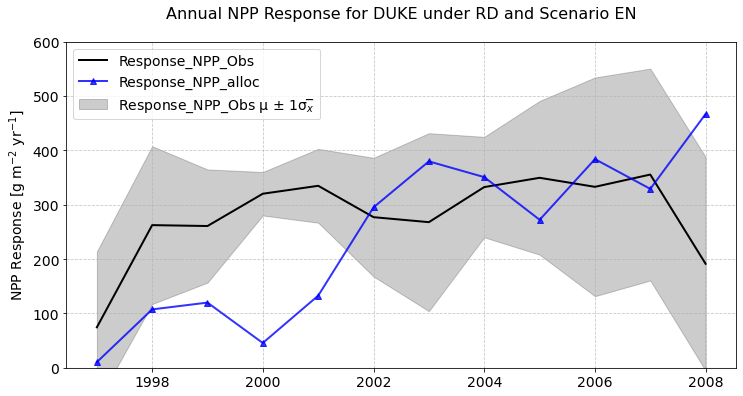

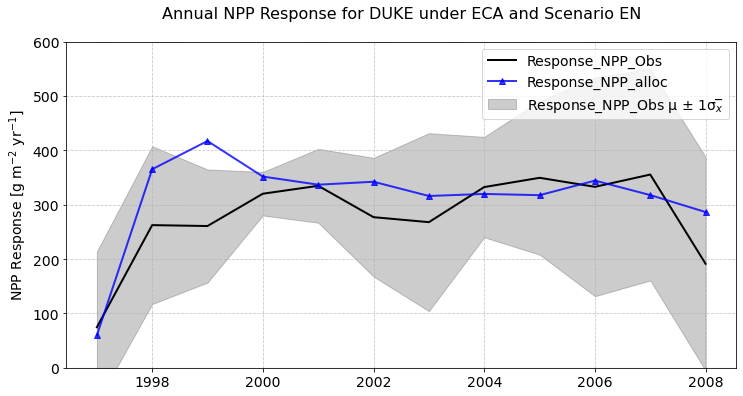

In [22]:
# NPP Response for ORNL
select_site = "US-DUK"
site = "DUKE"
li = 0  # for legend index
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12, 6))
    for var in var_names:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if key not in select_keys:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range(
                    "1996-01-01", "2007-12-31", freq="A"
                )  # Yearly data
                color_obs = "k"

                if (obs_plot == 1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = (
                        Mean_DF1[["YEAR", "NPP", "NUP"]]
                        - Mean_DF0[["YEAR", "NPP", "NUP"]]
                    )
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                        drop=True
                    )
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                        drop=True
                    )

                    Standard_error_DF = (
                        (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                        + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                    ) ** 0.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                    tmp_case = "Response"

                    # Extracting the relevant columns
                    years = Mean_DF["YEAR"]
                    mean_npp = Mean_DF["NPP"]
                    se_npp = Standard_error_DF["NPP"]
                    # Plot NPP with shaded error bars
                    plt.plot(
                        time,
                        mean_npp,
                        label=f"Response_NPP_Obs",
                        color=color_obs,
                        lw=2,
                    )
                    plt.fill_between(
                        time,
                        mean_npp - se_npp,
                        mean_npp + se_npp,
                        label=f"Response_NPP_Obs μ ± 1σ$_x̅$",
                        color=color_obs,
                        alpha=0.2,
                    )
                    data_plots_obs[site][var_obs][tmp_case] = {}
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                    #plt.fill_between(
                    #    time,
                    #    mean_npp - se_npp * 1.96,
                    #    mean_npp + se_npp * 1.96,
                    #    color=color_obs,
                    #    alpha=0.15,
                    #)

                    ran_once = True

                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var == "FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (
                        (ds[key][var.split("-")[0]] - ds[key][var.split("-")[1]])
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2][var.split("-")[0]]
                            - ds[key_eCO2][var.split("-")[1]]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )

                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label= tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + "NPP-ExResp",
                        color=color_line,
                        marker=marker_line,
                        linestyle="--",
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = (
                        (
                            ds[key]["FATES_CROOT_ALLOC"]
                            + ds[key]["FATES_FROOT_ALLOC"]
                            + ds[key]["FATES_LEAF_ALLOC"]
                            + ds[key]["FATES_SEED_ALLOC"]
                            + ds[key]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2]["FATES_CROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                            + ds[key_eCO2]["FATES_SEED_ALLOC"]
                            + ds[key_eCO2]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + var,
                        color=color_line,
                        marker=marker_line,
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)
                if False:
                    print(ds[key][var].long_name)
                plt.axhline(y=0, color="k", lw=2, alpha=0.02)
                plt.grid(
                    True, linestyle="--", alpha=0.7
                )  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"NPP Response [g m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(0, 600)
                plt.title(
                    f"Annual NPP Response for {site} under {sim_case} and Scenario {case_plot}\n",
                    fontsize=16,
                )
                # li+=1 # for legend index updating for a site

    print(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf"
    )

    

# Paper Plot

/Users/ud4/Documents/FACEMDS/Figures_Paper/LAIvsD2BL.xlsx

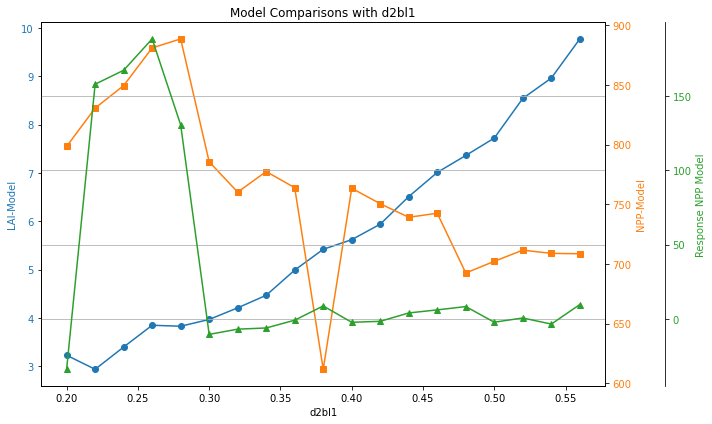

In [49]:
# Data
d2bl1 = [0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.52, 0.54, 0.56]
LAI_Model = [3.23, 2.94, 3.4, 3.85, 3.83, 3.97, 4.21, 4.47, 4.99, 5.42, 5.62, 5.94, 6.51, 7.01, 7.36, 7.72, 8.54, 8.96, 9.77]
NPP_Model = [798.42, 830.52, 849.39, 880.96, 888.50, 785.56, 760.13, 777.34, 763.86, 611.7, 763.39, 750.39, 739.06, 742.44, 692.35, 702.16, 711.53, 708.8, 708.5]
ResponseNPPModel = [-33.91, 158.08, 167.47, 188.59, 130.74, -10.4, -6.89, -6.09, -0.85, 8.74, -2.27, -1.6, 4.03, 6.1, 8.32, -2.2, 0.64, -3.47, 9.68]

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot LAI_Model on y-axis
ax1.set_xlabel('d2bl1')
ax1.set_ylabel('LAI-Model', color='tab:blue')
ax1.plot(d2bl1, LAI_Model, marker='o', color='tab:blue', label='LAI-Model')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for NPP_Model
ax2 = ax1.twinx()  
ax2.set_ylabel('NPP-Model', color='tab:orange')
ax2.plot(d2bl1, NPP_Model, marker='s', color='tab:orange', label='NPP-Model')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Create a third y-axis for ResponseNPPModel
ax3 = ax1.twinx()  
ax3.spines['right'].set_position(('outward', 60))  # Move the third y-axis outward
ax3.set_ylabel('Response NPP Model', color='tab:green')
ax3.plot(d2bl1, ResponseNPPModel, marker='^', color='tab:green', label='Response NPP Model')
ax3.tick_params(axis='y', labelcolor='tab:green')

# Title and layout adjustments
plt.title('Model Comparisons with d2bl1')
fig.tight_layout()  # Adjust the layout to prevent overlapping
plt.grid()

# Show the plot
plt.show()

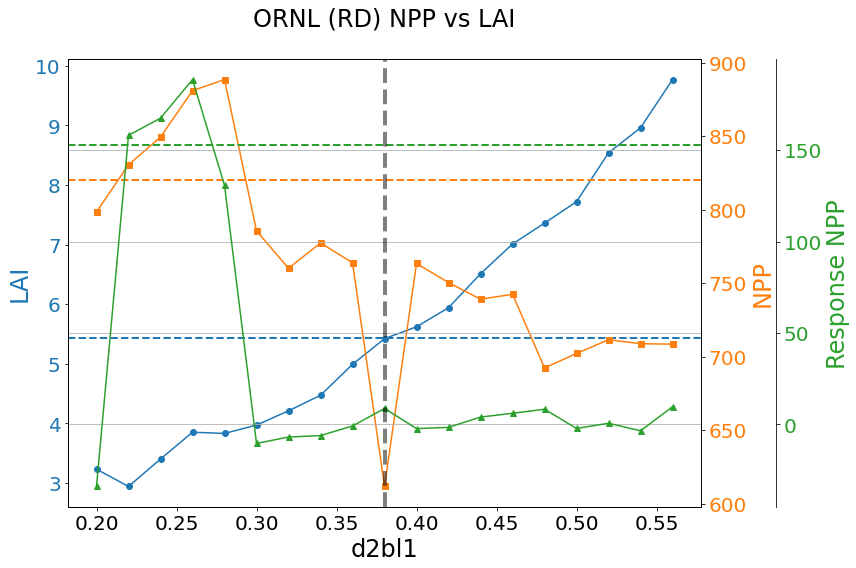

In [72]:
# Data
d2bl1 = [0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.52, 0.54, 0.56]
LAI_Model = [3.23, 2.94, 3.4, 3.85, 3.83, 3.97, 4.21, 4.47, 4.99, 5.42, 5.62, 5.94, 6.51, 7.01, 7.36, 7.72, 8.54, 8.96, 9.77]
NPP_Model = [798.42, 830.52, 849.39, 880.96, 888.50, 785.56, 760.13, 777.34, 763.86, 611.7, 763.39, 750.39, 739.06, 742.44, 692.35, 702.16, 711.53, 708.8, 708.5]
ResponseNPPModel = [-33.91, 158.08, 167.47, 188.59, 130.74, -10.4, -6.89, -6.09, -0.85, 8.74, -2.27, -1.6, 4.03, 6.1, 8.32, -2.2, 0.64, -3.47, 9.68]

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 8))  # Increase figure size

# Plot LAI_Model on y-axis
ax1.set_xlabel('d2bl1', fontsize=24)
ax1.set_ylabel('LAI', color='tab:blue', fontsize=24)
ax1.plot(d2bl1, LAI_Model, marker='o', color='tab:blue', label='LAI')
ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=20)
ax1.tick_params(axis='x', labelsize=20)

# Create a second y-axis for NPP_Model
ax2 = ax1.twinx()  
ax2.set_ylabel('NPP', color='tab:orange', fontsize=24)
ax2.plot(d2bl1, NPP_Model, marker='s', color='tab:orange', label='NPP')
ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=20)

# Create a third y-axis for ResponseNPPModel
ax3 = ax1.twinx()  
ax3.spines['right'].set_position(('outward', 75))  # Move the third y-axis outward
ax3.set_ylabel('Response NPP', color='tab:green', fontsize=24)
ax3.plot(d2bl1, ResponseNPPModel, marker='^', color='tab:green', label='Response NPP')
ax3.tick_params(axis='y', labelcolor='tab:green', labelsize=20)

# Add horizontal dashed lines
ax1.axhline(y=5.43, color='tab:blue', linestyle='--', linewidth=2)  # LAI
ax2.axhline(y=820, color='tab:orange', linestyle='--', linewidth=2)   # NPP
ax3.axhline(y=153, color='tab:green', linestyle='--', linewidth=2)   # ResponseNPPModel

# Add vertical line
plt.axvline(x=0.38, color='k', linestyle='--', linewidth=4, alpha = 0.5)  # Vertical line at x = 0.42

# Title and layout adjustments
plt.title(f'ORNL (RD) NPP vs LAI\n', fontsize=24)
fig.tight_layout()  # Adjust the layout to prevent overlapping
plt.grid()

# Show the plot
#plt.legend(fontsize=20)  # Set legend font size
plt.show()

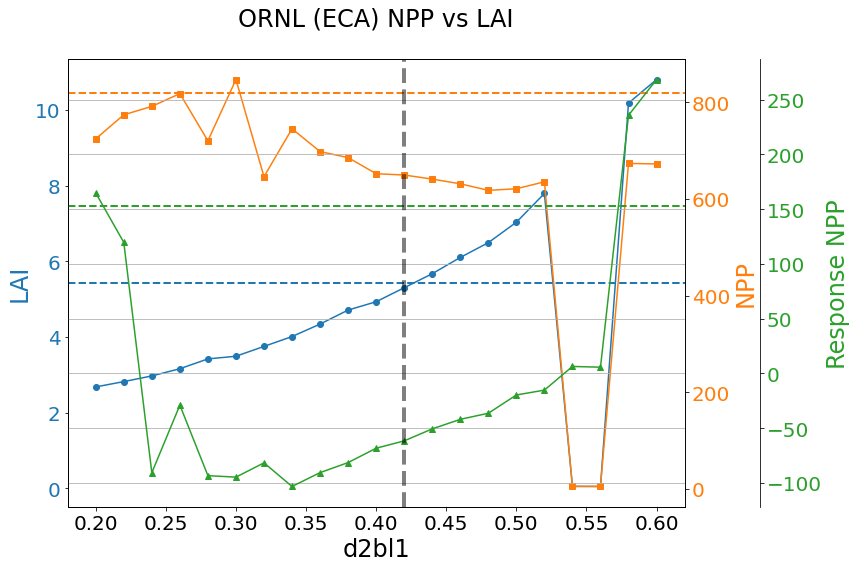

In [65]:
# Data
d2bl1 = [
    0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38,
    0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.52, 0.54, 0.56, 0.58, 0.6
]
LAI_Model = [
    2.68, 2.82, 2.97, 3.16, 3.42, 3.49, 3.75, 4.01, 4.34, 4.71,
    4.93, 5.3, 5.67, 6.1, 6.49, 7.03, 7.79, 0.05, 0.05, 10.18, 10.8
]
NPP_Model = [
    724.64, 774.37, 791.73, 818.17, 720.58, 847.3, 646.39, 745.41, 698.27, 685.82,
    652.46, 649.77, 641.36, 631.57, 618.08, 621.32, 635.71, 5.82, 5.38, 673.72, 672.68
]
ResponseNPPModel = [
    164.86, 119.7, -90.69, -28.93, -93.34, -94.68, -81.65, -103.2, -90.57, -81.39,
    -68.29, -61.57, -50.62, -41.91, -36.35, -19.67, -15.22, 6.4, 5.71, 235.79, 268.41
]

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 8))  # Increase figure size

# Plot LAI_Model on y-axis
ax1.set_xlabel('d2bl1', fontsize=24)
ax1.set_ylabel('LAI', color='tab:blue', fontsize=24)
ax1.plot(d2bl1, LAI_Model, marker='o', color='tab:blue', label='LAI')
ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=20)
ax1.tick_params(axis='x', labelsize=20)

# Create a second y-axis for NPP_Model
ax2 = ax1.twinx()  
ax2.set_ylabel('NPP', color='tab:orange', fontsize=24)
ax2.plot(d2bl1, NPP_Model, marker='s', color='tab:orange', label='NPP')
ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=20)

# Create a third y-axis for ResponseNPPModel
ax3 = ax1.twinx()  
ax3.spines['right'].set_position(('outward', 75))  # Move the third y-axis outward
ax3.set_ylabel('Response NPP', color='tab:green', fontsize=24)
ax3.plot(d2bl1, ResponseNPPModel, marker='^', color='tab:green', label='Response NPP')
ax3.tick_params(axis='y', labelcolor='tab:green', labelsize=20)

# Add horizontal dashed lines
ax1.axhline(y=5.43, color='tab:blue', linestyle='--', linewidth=2)  # LAI
ax2.axhline(y=820, color='tab:orange', linestyle='--', linewidth=2)   # NPP
ax3.axhline(y=153, color='tab:green', linestyle='--', linewidth=2)   # ResponseNPPModel

# Add vertical line
plt.axvline(x=0.42, color='k', linestyle='--', linewidth=4, alpha = 0.5)  # Vertical line at x = 0.42

# Title and layout adjustments
plt.title(f'ORNL (ECA) NPP vs LAI\n', fontsize=24)
fig.tight_layout()  # Adjust the layout to prevent overlapping
plt.grid()

# Show the plot
#plt.legend(fontsize=20)  # Set legend font size
plt.show()

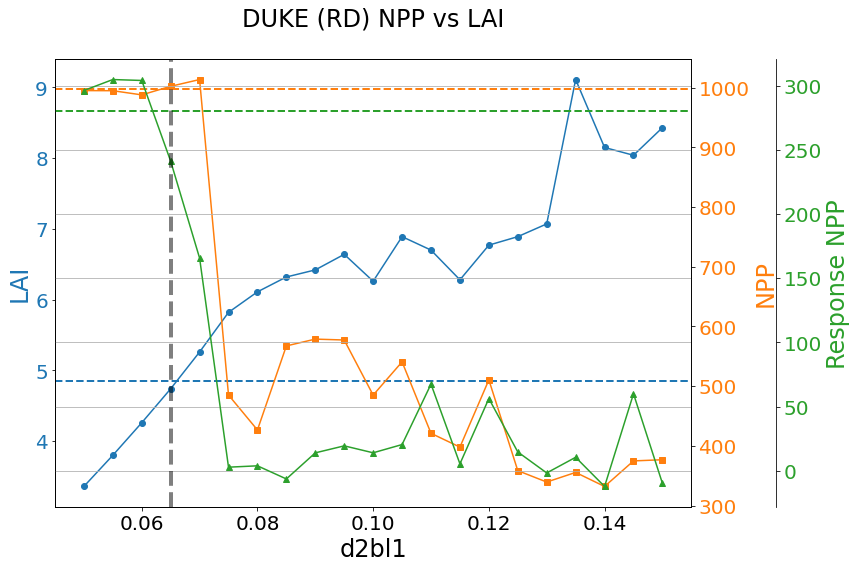

In [70]:
# Data
d2bl1 = [
    0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095,
    0.1, 0.105, 0.11, 0.115, 0.12, 0.125, 0.13, 0.135, 0.14, 0.145, 0.15
]
LAI_Model = [
    3.36, 3.8, 4.26, 4.74, 5.26, 5.82, 6.11, 6.32, 6.42, 6.64,
    6.26, 6.89, 6.7, 6.28, 6.77, 6.89, 7.07, 9.11, 8.15, 8.04, 8.43
]
NPP_Model = [
    995.06, 994.87, 987.87, 1002.23, 1013.56, 485.11, 426.58, 567.4, 578.78, 577.29,
    484.99, 540.67, 420.97, 397.91, 510.5, 358.44, 339.37, 355.47, 331.98, 374.77, 376.74
]
ResponseNPPModel = [
    296.25, 304.8, 304.09, 241.19, 165.7, 2.73, 3.79, -6.44, 13.9, 19.35,
    13.94, 20.36, 67.44, 5.33, 56.19, 14.6, -1.76, 10.43, -12.29, 59.92, -9.85
]

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 8))  # Increase figure size

# Plot LAI_Model on y-axis
ax1.set_xlabel('d2bl1', fontsize=24)
ax1.set_ylabel('LAI', color='tab:blue', fontsize=24)
ax1.plot(d2bl1, LAI_Model, marker='o', color='tab:blue', label='LAI')
ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=20)
ax1.tick_params(axis='x', labelsize=20)

# Create a second y-axis for NPP_Model
ax2 = ax1.twinx()  
ax2.set_ylabel('NPP', color='tab:orange', fontsize=24)
ax2.plot(d2bl1, NPP_Model, marker='s', color='tab:orange', label='NPP')
ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=20)

# Create a third y-axis for ResponseNPPModel
ax3 = ax1.twinx()  
ax3.spines['right'].set_position(('outward', 85))  # Move the third y-axis outward
ax3.set_ylabel('Response NPP', color='tab:green', fontsize=24)
ax3.plot(d2bl1, ResponseNPPModel, marker='^', color='tab:green', label='Response NPP')
ax3.tick_params(axis='y', labelcolor='tab:green', labelsize=20)

# Add horizontal dashed lines
ax1.axhline(y=4.85, color='tab:blue', linestyle='--', linewidth=2)  # LAI
ax2.axhline(y=998, color='tab:orange', linestyle='--', linewidth=2)   # NPP
ax3.axhline(y=280, color='tab:green', linestyle='--', linewidth=2)   # ResponseNPPModel

# Add vertical line
plt.axvline(x=0.065, color='k', linestyle='--', linewidth=4, alpha = 0.5)  # Vertical line at x = 0.42

# Title and layout adjustments
plt.title(f'DUKE (RD) NPP vs LAI\n', fontsize=24)
fig.tight_layout()  # Adjust the layout to prevent overlapping
plt.grid()

# Show the plot
#plt.legend(fontsize=20)  # Set legend font size
plt.show()

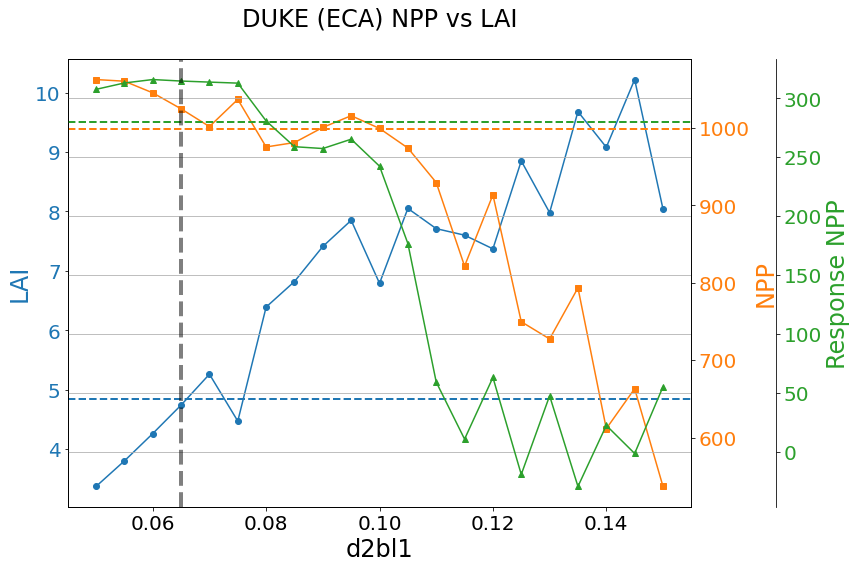

In [71]:
# Data
d2bl1 = [
    0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095,
    0.1, 0.105, 0.11, 0.115, 0.12, 0.125, 0.13, 0.135, 0.14, 0.145, 0.15
]
LAI_Model = [
    3.37, 3.8, 4.26, 4.74, 5.26, 4.47, 6.39, 6.82, 7.41, 7.85,
    6.79, 8.05, 7.71, 7.6, 7.37, 8.85, 7.98, 9.68, 9.08, 10.22, 8.04
]
NPP_Model = [
    1062.33, 1060.18, 1045.16, 1024.53, 1001.62, 1036.69, 975.28, 980.97, 1000.52, 1015.64,
    999.21, 973.91, 929.36, 821.45, 913.45, 749.62, 727.36, 793.33, 611.5, 663.19, 536.9
]
ResponseNPPModel = [
    307.55, 312.97, 315.87, 314.6, 313.7, 312.83, 280.74, 258.87, 257.33, 265.24,
    242.35, 176.72, 59.15, 10.73, 63.06, -19.25, 47.45, -29.45, 22.35, -1.47, 55.13
]

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 8))  # Increase figure size

# Plot LAI_Model on y-axis
ax1.set_xlabel('d2bl1', fontsize=24)
ax1.set_ylabel('LAI', color='tab:blue', fontsize=24)
ax1.plot(d2bl1, LAI_Model, marker='o', color='tab:blue', label='LAI')
ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=20)
ax1.tick_params(axis='x', labelsize=20)

# Create a second y-axis for NPP_Model
ax2 = ax1.twinx()  
ax2.set_ylabel('NPP', color='tab:orange', fontsize=24)
ax2.plot(d2bl1, NPP_Model, marker='s', color='tab:orange', label='NPP')
ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=20)

# Create a third y-axis for ResponseNPPModel
ax3 = ax1.twinx()  
ax3.spines['right'].set_position(('outward', 85))  # Move the third y-axis outward
ax3.set_ylabel('Response NPP', color='tab:green', fontsize=24)
ax3.plot(d2bl1, ResponseNPPModel, marker='^', color='tab:green', label='Response NPP')
ax3.tick_params(axis='y', labelcolor='tab:green', labelsize=20)

# Add horizontal dashed lines
ax1.axhline(y=4.85, color='tab:blue', linestyle='--', linewidth=2)  # LAI
ax2.axhline(y=998, color='tab:orange', linestyle='--', linewidth=2)   # NPP
ax3.axhline(y=280, color='tab:green', linestyle='--', linewidth=2)   # ResponseNPPModel

# Add vertical line
plt.axvline(x=0.065, color='k', linestyle='--', linewidth=4, alpha = 0.5)  # Vertical line at x = 0.42

# Title and layout adjustments
plt.title(f'DUKE (ECA) NPP vs LAI\n', fontsize=24)
fig.tight_layout()  # Adjust the layout to prevent overlapping
plt.grid()

# Show the plot
#plt.legend(fontsize=20)  # Set legend font size
plt.show()